Survival Probability: 0.3460


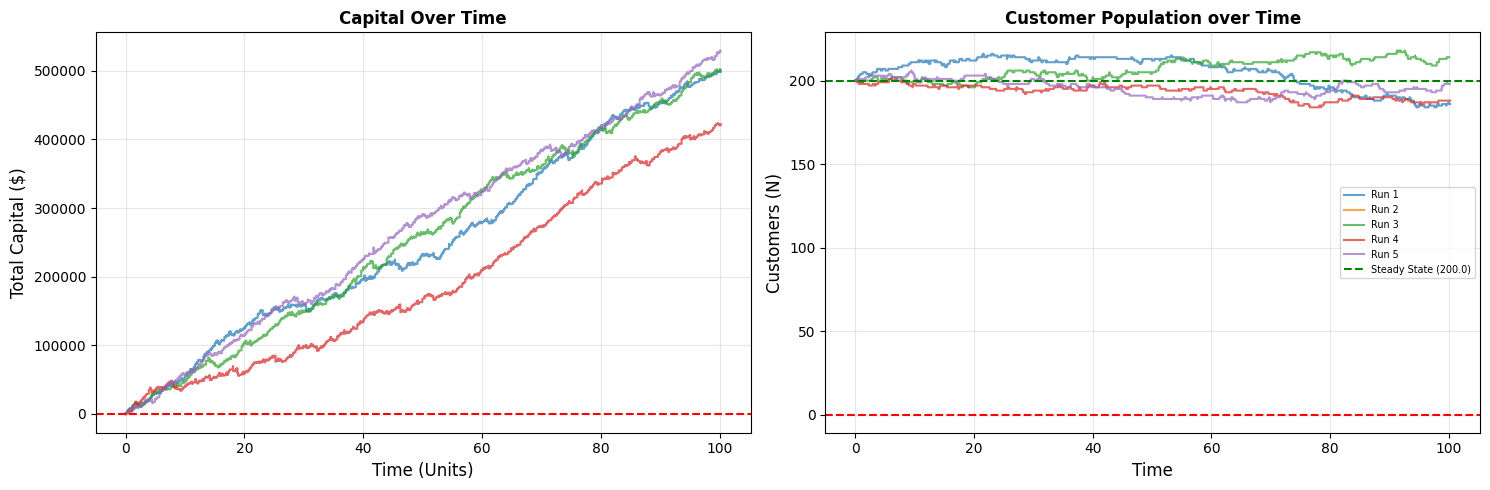

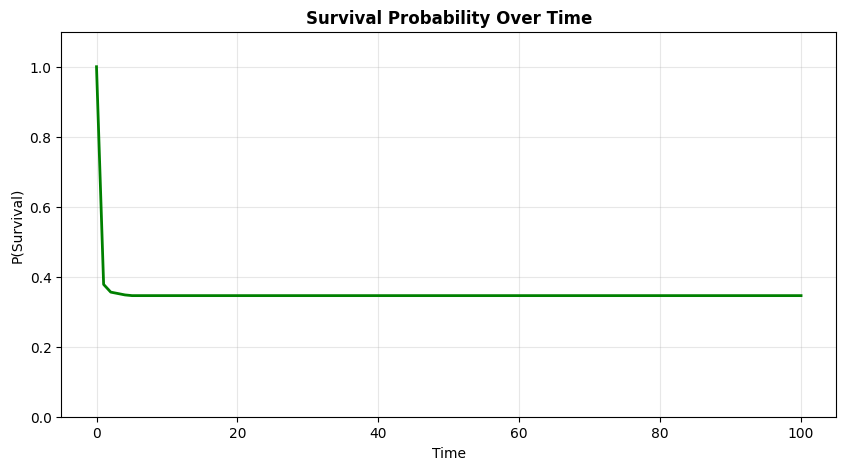

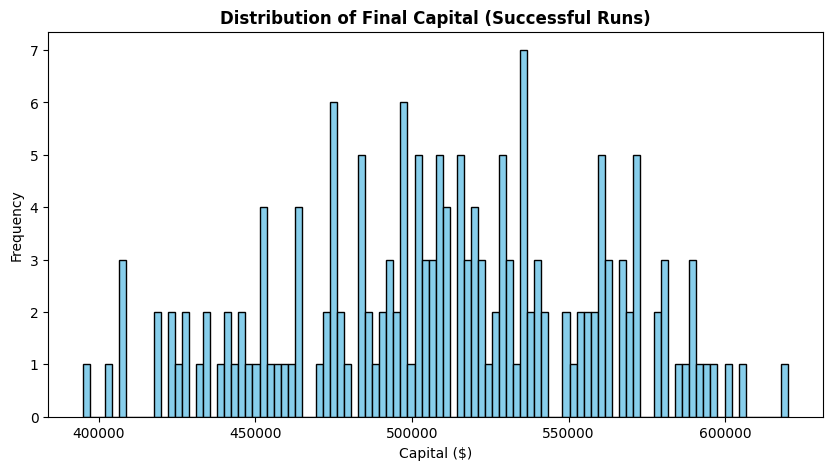

In [1]:
import math as m
import random as rand
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple, List

class simulation:
    def __init__(self, cRate, sRate, rRate, pRate, cDist, iCap, iCust):
        self.claimRate = cRate
        self.signRate = sRate
        self.remainRate = rRate
        self.payRate = pRate
        self.claimDistribution = cDist
        self.initialCapital = iCap
        self.initialCustomer = iCust
        #for the plotting data later
        self.recorded_paths = []
        self.final_capitals = []
        self.ruin_times = []

    def getNextEvent(self, numCustomer) -> Tuple[float, str]:
        rate_sign = self.signRate
        rate_leave = numCustomer * self.remainRate
        rate_claim = numCustomer * self.claimRate
        total_rate = rate_sign + rate_leave + rate_claim

        if total_rate <= 0:
            raise Exception("Invalid rate")
        #should be the equivalent to pulling from an exponential distribution
        #since u1,u2 are uniform random variables we use log/rate to simulate
        u1 = rand.random()
        dt = -m.log(u1) / total_rate

        u2 = rand.random()
        prob_sign = rate_sign / total_rate
        prob_leave = rate_leave / total_rate

        if u2 < prob_sign:
            event_type = "sign"
        elif u2 < (prob_sign + prob_leave):
            event_type = "leave"
        else:
            event_type = "claim"

        return dt, event_type

    def runSimulation(self, time):
      #please note that we moved all the plotting code out of here so we coudl
      #better fit the code into our slides
        simTime = 0
        customerNum = self.initialCustomer
        capital = self.initialCapital

        #Track data for plotting
        t_hist, cap_hist, cust_hist = [0], [capital], [customerNum]

        while simTime < time:
            dt, event_type = self.getNextEvent(customerNum)
            simTime += dt
            capital += customerNum * self.payRate * dt
            if event_type == "sign":
                customerNum += 1
            elif event_type == "leave":
                customerNum -= 1
            elif event_type == "claim":
                capital -= self.claimDistribution()

            #Record state for the simulation
            t_hist.append(simTime)
            cap_hist.append(capital)
            cust_hist.append(customerNum)
            if capital < 0:
                return False, simTime, (t_hist, cap_hist, cust_hist)

        return True, capital, (t_hist, cap_hist, cust_hist)

    def computeProbability(self, time, simCount, plotCount=5):
        self.recorded_paths = []
        self.final_capitals = []
        self.ruin_times = []
        successCount = 0
        total_capial = 0

        for i in range(simCount):
            res, cap, history = self.runSimulation(time)
            if res:
                successCount += 1
                self.final_capitals.append(cap)
            else:
              self.ruin_times.append(cap)

            total_capial += cap

            #Save the first few runs for plotting (omitted from the slides)
            if i < plotCount:
                self.recorded_paths.append({'history': history, 'success': res})

        return successCount / simCount, total_capial / simCount

    def plotResults(self, total_time, simCount):
      #Steady State calculation of : Sign Rate / Leave Rate
        n_steady_state = self.signRate / self.remainRate

        # First part of the blocked together graphs is to get hte customer and captial
        #over time plots so if you dont see them scroll up
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

        # We use a small maxed out loop for labels
        # this is to avoid clutter in the legend if simCount variable is high
        for idx, path in enumerate(self.recorded_paths):
            t, cap, cust = path['history']
            label = f"Run {idx+1}" if idx < 10 else None # Label first 10
            ax1.step(t, cap, where='post', label=label, alpha=0.7)
            ax2.step(t, cust, where='post', label=label, alpha=0.7)

        #Capital Graph Formatting
        ax1.axhline(0, color='red', linestyle='--')
        ax1.set_xlabel("Time (Units)", fontsize=12)
        ax1.set_ylabel("Total Capital ($)", fontsize=12)
        ax1.set_title("Capital Over Time", fontweight='bold')
        ax1.grid(True, alpha=0.3)

        #Customers over time Formatting
        ax2.axhline(0, color='red', linestyle='--')
        ax2.axhline(n_steady_state, color='green', linestyle='--',
                    label=f'Steady State ({n_steady_state:.1f})')
        ax2.set_xlabel("Time", fontsize=12)
        ax2.set_ylabel("Customers (N)", fontsize=12)
        ax2.set_title("Customer Population over Time", fontweight='bold')
        ax2.grid(True, alpha=0.3)
        ax2.legend(fontsize='x-small', loc='best')

        plt.tight_layout()
        plt.show()

        #Survival probability plot
        plt.figure(figsize=(10, 5))
        sorted_ruins = sorted(self.ruin_times)
        time_axis = np.linspace(0, total_time, 100)
        survival_prob = [ (simCount - sum(1 for rt in sorted_ruins if rt <= t)) / simCount for t in time_axis]

        plt.plot(time_axis, survival_prob, color='green', lw=2)
        plt.title("Survival Probability Over Time", fontweight='bold')
        plt.xlabel("Time")
        plt.ylabel("P(Survival)")
        plt.ylim(0, 1.1)
        plt.grid(True, alpha=0.3)
        plt.show()

        #Captial histogram only for successful runs
        plt.figure(figsize=(10, 5))
        plt.hist(self.final_capitals, bins=100, edgecolor='black', color='skyblue')
        plt.title("Distribution of Final Capital (Successful Runs)", fontweight='bold')
        plt.xlabel("Capital ($)")
        plt.ylabel("Frequency")
        plt.show()


# running logic put variables here and see teh data
def exp_dist():
  return np.random.exponential(1000)

#redundant and without explanation sim = simulation(0.05, 7, 0.018, 100, exp_dist, 1000, 200)
#simulation function object thing
#parameters for a quick telling of how the probability over time works
sim = simulation(
    cRate=0.05,    #lamda (claim rate)
    sRate=1,       #nu (sign rate)
    rRate=0.005,   #mu (leave rate)
    pRate=75,     #c (premium pay)
    cDist=exp_dist, #get the distribution F
    iCap=200,     #a0 (initial capital)
    iCust=200      #n0 (initial customers)
)
#pass in max time and how many iterations of running this

time = 100
iterations = 500
prob, avg = sim.computeProbability(time, iterations)

print(f"Survival Probability: {prob:.4f}")
sim.plotResults(time, iterations)